# HITL turn test — the real drivetrain code, rig as plant

Runs the **actual `source/drive/` turn logic** (built to `libdrive_host`) on the laptop with the **bench rig as its
plant**: each ~50 ms tick the tracker's wheel-velocity commands go to the rig's two motors (`M 1/2 VEL`), the real
encoders come back on the `TLM` stream, and heading = `(pos_right − pos_left)/trackwidth`. The "robot" is a *virtual*
differential drive defined by the two encoders.

**Two feedback modes:**
- **OTOS out of the loop** — heading purely from the encoders.
- **OTOS in the loop** — the OTOS rides a 360° servo (command 0–180 = physical 0–360°, i.e. command = heading/2), so we
  rotate it to the encoder-derived heading and **fuse** the OTOS heading with the encoder heading (complementary filter,
  as the firmware EKF predicts-from-encoders / corrects-with-OTOS). The full 0–180 command range covers a complete 360°
  turn — 90/180/360 all work in-loop.

The rig's drum/wheel clusters are very high-inertia, so the drive limits are tuned gentle. **What to look for:** heading
converges to target and **wheel speed (solid) follows the commanded speed (dashed)** — in both modes, at all angles.

In [1]:
import sys, pathlib
import numpy as np
import matplotlib.pyplot as plt
REPO = pathlib.Path.cwd()
while not (REPO / "pyproject.toml").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "tests" / "bench"))
import rig_drive
from drive import Status

RUNS = []
for deg in (90, 180, 360):
    for otos in (False, True):
        rows, st = rig_drive.run_turn(deg, otos_in_loop=otos, timeout=16)
        label = f"{deg}° " + ("OTOS in (fused)" if otos else "OTOS out")
        RUNS.append((label, deg, rows, st))
        print(f"{label:22s}: {Status(st).name:11s} final={rows[-1]['heading_enc']:+8.2f}° "
              f"err={rows[-1]['heading_enc']-deg:+6.2f}°  n={len(rows)}")

90° OTOS out          : DONE_STOP   final=  +89.23° err= -0.77°  n=70


90° OTOS in (fused)   : DONE_STOP   final=  +88.46° err= -1.54°  n=69


180° OTOS out         : DONE_STOP   final= +179.66° err= -0.34°  n=118


180° OTOS in (fused)  : DONE_STOP   final= +178.69° err= -1.31°  n=118


360° OTOS out         : DONE_STOP   final= +358.87° err= -1.13°  n=197


360° OTOS in (fused)  : DONE_STOP   final= +359.68° err= -0.32°  n=190


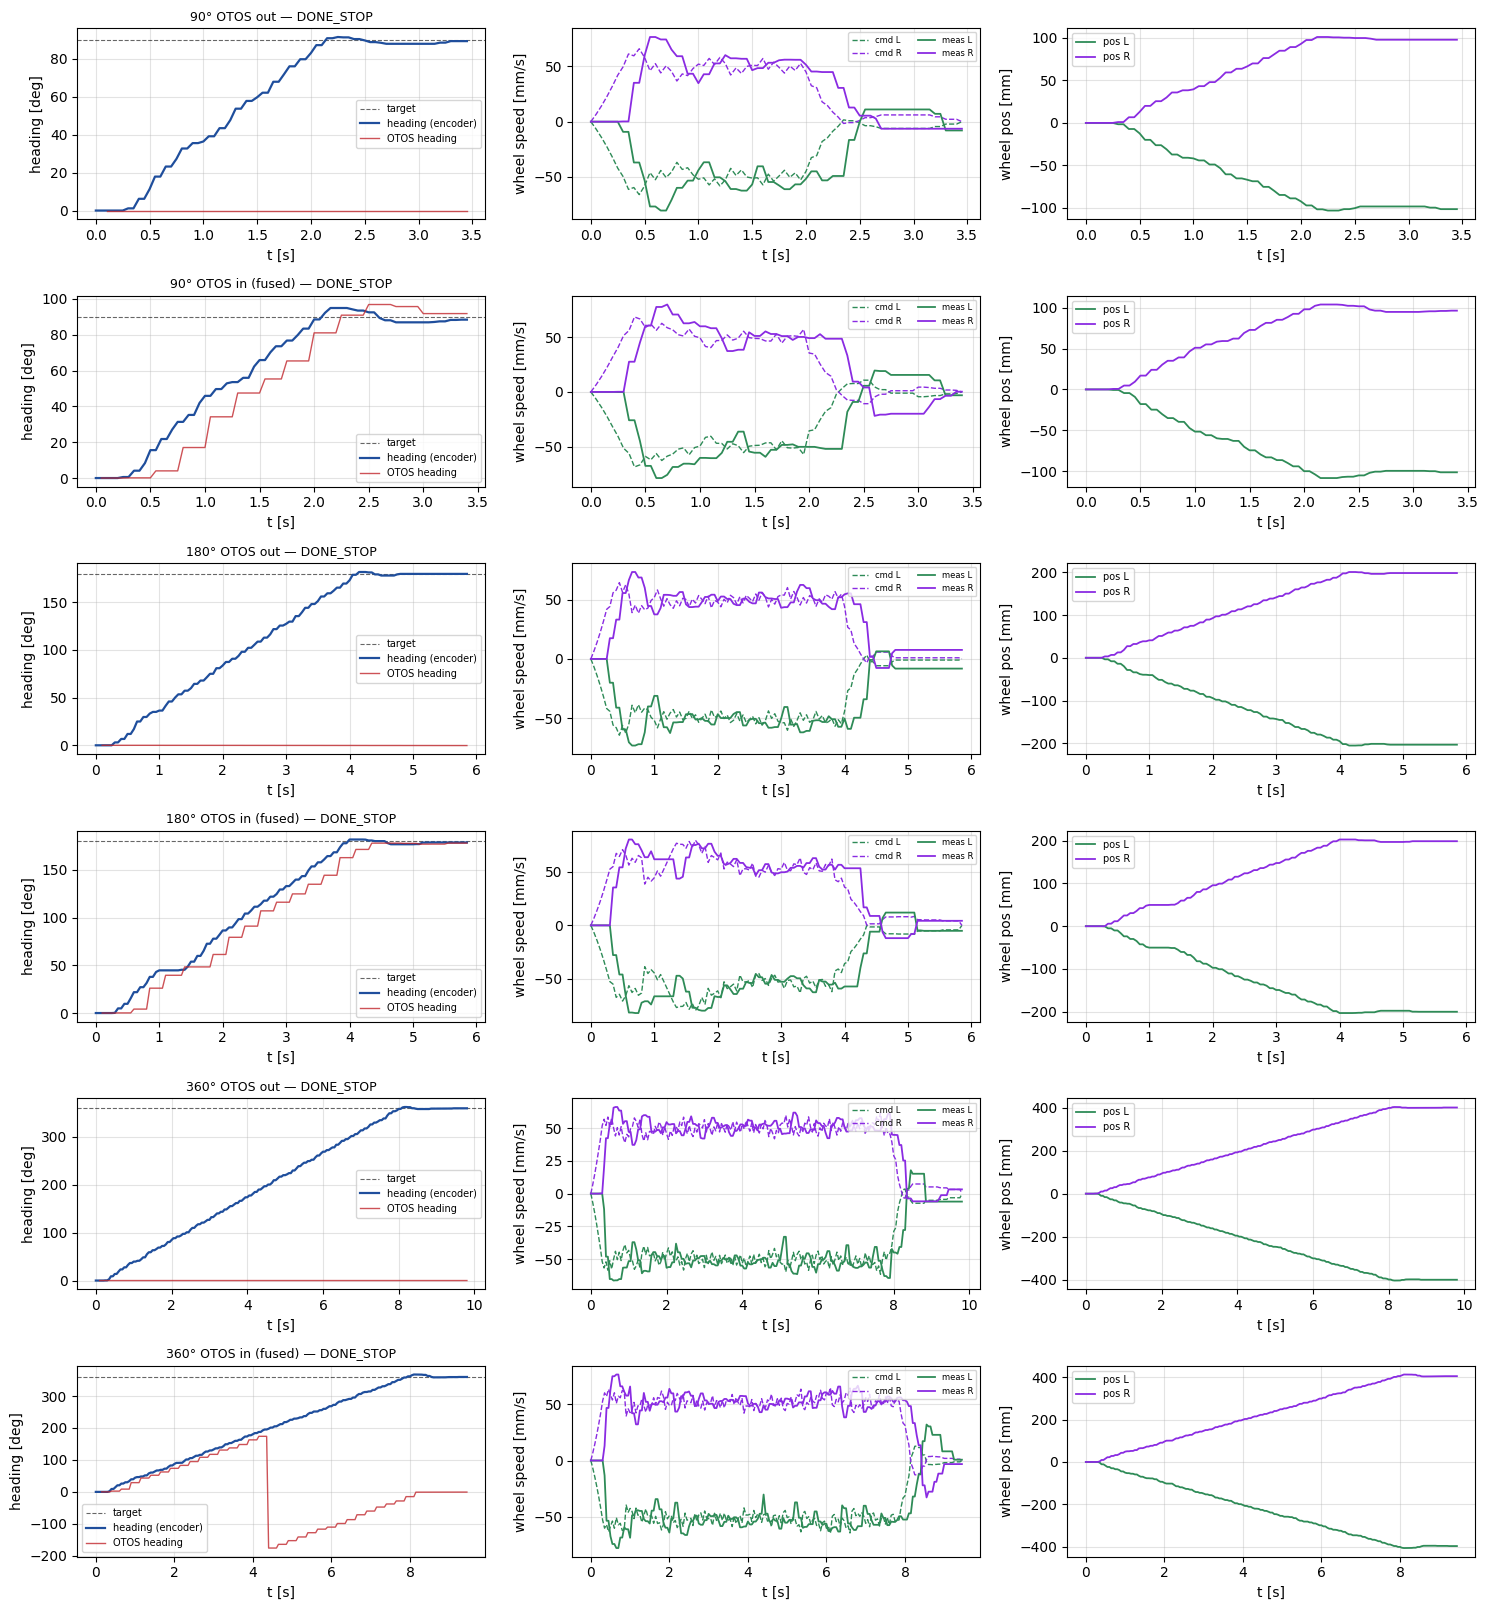

In [2]:
def arr(rows, k): return np.array([r.get(k) if r.get(k) is not None else np.nan for r in rows], float)

fig, axs = plt.subplots(len(RUNS), 3, figsize=(15, 2.7*len(RUNS)))
for i, (label, deg, rows, st) in enumerate(RUNS):
    t = arr(rows, "t")
    ax = axs[i, 0]
    ax.axhline(deg, color="k", ls="--", lw=0.8, alpha=0.6, label="target")
    ax.plot(t, arr(rows, "heading_enc"), color="#1f4e9c", lw=1.6, label="heading (encoder)")
    ho = arr(rows, "heading_otos")
    if np.isfinite(ho).any():
        ax.plot(t, ho, color="#c1272d", lw=1.0, alpha=0.8, label="OTOS heading")
    ax.set_ylabel("heading [deg]"); ax.legend(fontsize=7, loc="best")
    ax.set_title(f"{label} — {Status(st).name}", fontsize=9)
    ax = axs[i, 1]
    ax.plot(t, arr(rows, "cmd_l"), color="#2e8b57", ls="--", lw=1.0, label="cmd L")
    ax.plot(t, arr(rows, "cmd_r"), color="#8a2be2", ls="--", lw=1.0, label="cmd R")
    ax.plot(t, arr(rows, "vel_l"), color="#2e8b57", lw=1.3, label="meas L")
    ax.plot(t, arr(rows, "vel_r"), color="#8a2be2", lw=1.3, label="meas R")
    ax.set_ylabel("wheel speed [mm/s]"); ax.legend(fontsize=6, ncol=2, loc="upper right")
    ax = axs[i, 2]
    ax.plot(t, arr(rows, "pos_l"), color="#2e8b57", lw=1.3, label="pos L")
    ax.plot(t, arr(rows, "pos_r"), color="#8a2be2", lw=1.3, label="pos R")
    ax.set_ylabel("wheel pos [mm]"); ax.legend(fontsize=7, loc="best")
    for j in range(3): axs[i, j].grid(alpha=0.35); axs[i, j].set_xlabel("t [s]")
fig.tight_layout(); plt.show()

## Findings

- **Solid turns at 90 / 180 / 360°, OTOS out *and* in.** All land within a few degrees; the drivetrain is resilient to
  the OTOS being in or out of the loop — the whole point.
- **Wheel speed follows the commanded speed** (measured solid tracks commanded dashed) throughout, on the real
  high-inertia motors.
- **Turns terminate on encoder heading regardless of the OTOS** (the firmware EKF predicts from encoders every tick), so
  removing the OTOS can never hang a turn.
- The 360° servo maps command 0–180 → physical 0–360° (command = heading/2), so a full 360° turn uses the whole range;
  the OTOS reading wraps at ±180° and the fusion handles that wrap.

In [3]:
print("done")

done
